# Notebook 03: Evaluation and Threshold Tuning

This notebook evaluates the saved Notebook 02 modelling artefacts, selects the final decision threshold using validation data, and reports the held-out test performance of the selected XGBoost candidate. It also produces the evaluation outputs needed to assess model performance and threshold behaviour for later live scoring.

## 1. Configuration

Shared paths and evaluation dependencies are loaded, while saved model artefacts are reused without retraining.

In [1]:
from __future__ import annotations
import json
import os
from pathlib import Path
from typing import Any, Iterable, Optional, Sequence
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Align a candidate dataframe to the row order and keys defined by a split manifest
def align_frame_to_manifest(
    manifest_df: pd.DataFrame,
    candidate_df: pd.DataFrame,
    key_columns: Sequence[str],
    candidate_columns: Optional[Sequence[str]] = None,
    label: str = "candidate frame",
) -> pd.DataFrame:
    # Check that all alignment key columns exist in both dataframes
    missing_keys = [
        column
        for column in key_columns
        if column not in manifest_df.columns or column not in candidate_df.columns
    ]
    # Stop if alignment keys are missing
    if missing_keys:
        raise ValueError(f"Cannot align {label}. Missing key columns: {missing_keys}")

    # Select the candidate columns to carry through alignment
    candidate_columns = list(candidate_columns or candidate_df.columns)
    candidate_subset = candidate_df[candidate_columns].copy()
    
    # Detect duplicate candidate rows for the same key combination
    duplicate_mask = candidate_subset.duplicated(subset=list(key_columns), keep=False)

    # Stop if duplicate key rows are found
    if candidate_subset.duplicated(subset=list(key_columns), keep=False).any():
        raise ValueError(f"Cannot align {label}. Duplicate key rows detected.")

    # Merge candidate rows onto the manifest to preserve manifest order
    aligned = manifest_df[list(key_columns)].merge(
        candidate_subset,
        on=list(key_columns),
        how="left",
        sort=False,
    )
    # Identify non-key columns used to confirm that matches were found
    non_key_columns = [column for column in candidate_columns if column not in key_columns]
    # Stop if no candidate values matched the manifest rows
    if non_key_columns and aligned[non_key_columns].isna().all(axis=None) and len(aligned) > 0:
        raise ValueError(f"Alignment failed for {label}. No matching rows were found.")
    # Return the manifest-aligned dataframe
    return aligned

# Resolve the project data root from an environment variable or preferred fallback paths
def resolve_data_root(
    env_var: str = "PHISHING_PROJECT_DATA_ROOT",
    preferred: Optional[Iterable[Path]] = None,
) -> Path:
    # Read the optional data root environment variable
    env_value_raw = os.environ.get(env_var, "").strip()
    env_path = Path(env_value_raw) if env_value_raw else None

    # Build the ordered list of candidate data roots
    candidates: list[Path] = []
    if env_path is not None:
        candidates.append(env_path)
    if preferred is not None:
        candidates.extend(preferred)
    candidates.extend([Path("/datasets"), Path("datasets"), Path(".")])

    # Return the first existing candidate path
    for candidate in candidates:
        try:
            if candidate.exists():
                return candidate
        except Exception:
            continue
    # Fall back to the current directory when no candidate exists
    return Path(".")

# Resolve the base data directory for notebook inputs and outputs
DATA_ROOT = resolve_data_root(preferred=[Path("/datasets"), Path("datasets"), Path(".")])

# Define standard project directories used by the notebook
PROCESSED = DATA_ROOT / "processed"
MODELS_DIR = DATA_ROOT / "models"
EVALUATION_DIR = DATA_ROOT / "evaluation"
AUDIT_DIR = DATA_ROOT / "audit"
OUTPUTS_DIR = DATA_ROOT / "outputs"

# Reuse the models directory as the output models directory
OUTPUTS_MODELS_DIR = MODELS_DIR

In [2]:
# Load a JSON file into a Python dictionary
def load_json(path: Path) -> dict[str, Any]:
    with open(path, "r") as f:
        # Parse and return the JSON contents
        return json.load(f)
        
# Resolve the first available output file from candidate names and search directories
def resolve_output_path(search_dirs: list[Path], candidates: list[str], label: str) -> Path:
    # Search each candidate filename across the configured directories
    for filename in candidates:
        for directory in search_dirs:
            path = directory / filename
            # Return the first matching existing path
            if path.exists():
                return path
    # Return the preferred fallback path when no existing file is found
    return search_dirs[0] / candidates[0]

# Load Notebook 2 model selection results from saved summaries or comparison tables
def load_main_results(search_dirs: list[Path] = [EVALUATION_DIR, OUTPUTS_DIR]) -> pd.DataFrame:
    # Define possible summary filenames from Notebook 2
    summary_candidates = ["notebook2_model_comparison_summary.json", "model_comparison_summary.json"]
    # Locate the first available model comparison summary
    summary_path = next((directory / name for directory in search_dirs for name in summary_candidates if (directory / name).exists()), None)
    # Prefer the compact JSON summary when available
    if summary_path is not None:
        summary = load_json(summary_path)
        final_selected = summary.get("final_selected_model")
        final_metrics = summary.get("final_selected_model_validation_metrics", {})
        # Return the final selected row when the summary stores one directly
        if isinstance(final_selected, dict) and final_selected:
            family = str(
                summary.get(
                    "final_selected_model_family",
                    "hybrid" if "+" in str(final_selected.get("model", "")) else "supervised",
                )
            )
            # Combine selected model details with validation metrics and family label
            row = {**final_selected, **{f"val_{key}": value for key, value in final_metrics.items() if key in {"precision", "recall", "f1", "roc_auc", "pr_auc"}}, "family": family}
            # Ensure the selected row has a model name
            row.setdefault("model", str(summary.get("final_selected_model_name", final_selected.get("model", ""))))
            # Return the selected model as a one-row dataframe
            return pd.DataFrame([row])
        # Fall back to older summary structure with supervised and hybrid rows
        rows = []
        for family in ["supervised", "hybrid"]:
            for row in summary.get(family, []):
                rows.append({**row, "family": family})
        # Return rows from the older summary format when present
        if rows:
            return pd.DataFrame(rows)
    # Fall back to saved comparison CSV files
    frames = []
    # Load supervised and hybrid comparison tables when available
    for family, filename in [
        ("supervised", "comparison_table_B_supervised.csv"),
        ("hybrid", "comparison_table_C_hybrid.csv"),
    ]:
        path = resolve_output_path(search_dirs, [filename], f"{family} comparison table")
        # Add the family label to each loaded comparison table
        if path.exists():
            frames.append(pd.read_csv(path).assign(family=family))
    # Return combined comparison rows or an empty dataframe
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# Select the best final model candidate using validation metrics
def select_final_candidate(results: pd.DataFrame) -> pd.Series:
    # Define the validation metrics required for ranking
    required_columns = ["val_pr_auc", "val_roc_auc", "val_f1"]
    # Rank candidates by PR AUC, then ROC AUC, then F1
    ranked = results.sort_values(
        ["val_pr_auc", "val_roc_auc", "val_f1"],
        ascending=False,
    ).reset_index(drop=True)
    # Return the top-ranked candidate
    return ranked.iloc[0]

# Load the Notebook 2 split manifest used to align downstream evaluation rows
def load_split_manifest(audit_dir: Path = AUDIT_DIR) -> pd.DataFrame:
    # Define the split manifest path
    manifest_path = audit_dir / "notebook2_split_manifest.csv"
    if manifest_path.exists():
        return pd.read_csv(manifest_path)
    # Return an empty manifest with the expected schema when unavailable
    return pd.DataFrame(columns=["domain", "registered_domain", "label", "source_dataset", "split"])

# Load Notebook 2 model-selection results
main_results = load_main_results()

# Select the final candidate from validation-ranked results
final_candidate = select_final_candidate(main_results)

# Store final model name and family
FINAL_MODEL_NAME = str(final_candidate["model"])
FINAL_MODEL_FAMILY = str(final_candidate["family"])

# Load split manifest
split_manifest_df = load_split_manifest()

In [3]:
# Resolve the prediction file path and score column for a model and split
def prediction_path_and_score_column(model_label: str, split: str, search_dirs: list[Path] = [EVALUATION_DIR, OUTPUTS_DIR]) -> tuple[Path, str]:
    # Use hybrid prediction filenames when the model combines anomaly and supervised components
    if "+" in model_label:
        anomaly_name, supervised_name = model_label.split("+", 1)
        # Define supported hybrid prediction filename patterns
        filename_candidates = [
            f"notebook2_{split}_predictions_hybrid_{anomaly_name.lower()}_{supervised_name.lower()}.csv",
            f"{split}_predictions_hybrid_{anomaly_name.lower()}_{supervised_name.lower()}.csv",
        ]
        # Return the resolved hybrid prediction path and probability score column
        return resolve_output_path(search_dirs, filename_candidates, f"{split} hybrid predictions"), "pred_prob"
    # Use unsupervised prediction filenames for anomaly-only models
    if model_label in {"IF", "OCSVM"}:
        # Define supported unsupervised prediction filename patterns
        filename_candidates = [
            f"notebook2_{split}_predictions_unsupervised_{model_label.lower()}.csv",
            f"{split}_predictions_unsupervised_{model_label.lower()}.csv",
        ]
        # Return the resolved unsupervised prediction path and anomaly score column
        return resolve_output_path(search_dirs, filename_candidates, f"{split} unsupervised predictions"), "anomaly_score"
    # Define supported supervised prediction filename patterns
    filename_candidates = [
        f"notebook2_{split}_predictions_supervised_{model_label.lower()}.csv",
        f"{split}_predictions_supervised_{model_label.lower()}.csv",
    ]
    # Return the resolved supervised prediction path and probability score column
    return resolve_output_path(search_dirs, filename_candidates, f"{split} supervised predictions"), "pred_prob"

# Load saved predictions for a model and split
def load_predictions(model_label: str, split: str) -> tuple[pd.DataFrame, str]:
    # Resolve the prediction file and score column
    path, score_col = prediction_path_and_score_column(model_label, split)
    # Read the prediction CSV
    pred_df = pd.read_csv(path)
    # Return predictions with their score column name
    return pred_df, score_col

# Select stable key columns shared by the manifest and candidate dataframe
def manifest_key_columns(manifest_df: pd.DataFrame, candidate_df: pd.DataFrame) -> list[str]:
    # Define preferred alignment keys in priority order
    preferred = ["domain", "registered_domain", "observed_at", "label", "source_dataset"]
    # Keep keys that exist in both dataframes
    keys = [column for column in preferred if column in manifest_df.columns and column in candidate_df.columns]
    # Return the shared alignment keys
    return keys

# Align prediction rows to the split manifest order
def align_predictions_to_manifest(split_name: str, prediction_df: pd.DataFrame, score_col: str) -> pd.DataFrame:
    # Return predictions unchanged when no split manifest is available
    if split_manifest_df.empty:
        return prediction_df
    # Filter the manifest to the requested split
    manifest_split_df = split_manifest_df[split_manifest_df["split"].eq(split_name)].reset_index(drop=True)
    # Determine shared alignment keys between manifest and predictions
    keys = manifest_key_columns(manifest_split_df, prediction_df)
    # Select keys and prediction columns needed after alignment
    candidate_columns = keys + [column for column in ["split", score_col, "pred_label"] if column in prediction_df.columns]
    # Align prediction rows to manifest order and keys
    return align_frame_to_manifest(
        manifest_split_df,
        prediction_df,
        key_columns=keys,
        candidate_columns=candidate_columns,
        label=f"{split_name} predictions",
    )

# Load raw validation and test predictions for the final model
val_pred_df_raw, SCORE_COLUMN = load_predictions(FINAL_MODEL_NAME, "val")
test_pred_df_raw, test_score_col = load_predictions(FINAL_MODEL_NAME, "test")

# Confirm validation and test prediction files use the same score column
assert SCORE_COLUMN == test_score_col

# Align validation and test predictions to the Notebook 2 split manifest
val_pred_df = align_predictions_to_manifest("val", val_pred_df_raw, SCORE_COLUMN)
test_pred_df = align_predictions_to_manifest("test", test_pred_df_raw, SCORE_COLUMN)

## 2. Data Loading

Saved comparison tables and prediction files are loaded from the Notebook 02 output directories.

In [4]:
# Build a threshold grid from probability scores or score quantiles
def threshold_grid(scores: np.ndarray, n_steps: int = 201) -> np.ndarray:
    # Convert scores to a numeric array
    scores = np.asarray(scores, dtype=float)
    # Use an evenly spaced probability grid when scores are bounded between zero and one
    if np.nanmin(scores) >= 0.0 and np.nanmax(scores) <= 1.0:
        return np.linspace(0.0, 1.0, n_steps)
    # Use score quantiles for unbounded anomaly-style scores
    return np.unique(np.quantile(scores, np.linspace(0.01, 0.99, n_steps)))

# Calculate precision, recall, and F1 at a selected threshold
def metrics_at_threshold(y_true: np.ndarray, scores: np.ndarray, threshold: float) -> dict[str, float]:
    # Convert scores into binary predictions using the threshold
    y_pred = (scores >= threshold).astype(int)
    # Return the threshold performance metrics
    return {
        "threshold": float(threshold),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }
    
# Evaluate model performance across all candidate thresholds
def tune_thresholds(y_true: np.ndarray, scores: np.ndarray) -> pd.DataFrame:
    # Calculate metrics for every threshold in the grid
    rows = [metrics_at_threshold(y_true, scores, threshold) for threshold in threshold_grid(scores)]
    # Return the full threshold tuning table
    return pd.DataFrame(rows)

# Set the minimum recall required for the high-precision operating point
MIN_RECALL_FOR_HIGH_PRECISION = 0.80

# Set the minimum precision required for the high-recall operating point
MIN_PRECISION_FOR_HIGH_RECALL = 0.90

# Extract validation labels and scores from aligned predictions
val_y = val_pred_df["label"].to_numpy()
val_scores = val_pred_df[SCORE_COLUMN].to_numpy()

# Evaluate validation performance across threshold candidates
threshold_grid_results = tune_thresholds(val_y, val_scores)

# Select the threshold with the best F1 score
best_f1_row = threshold_grid_results.sort_values(
    ["f1", "precision", "recall"], ascending=False
).iloc[0]

# Restrict high-precision search to thresholds meeting the minimum recall target
high_precision_pool = threshold_grid_results[threshold_grid_results["recall"] >= MIN_RECALL_FOR_HIGH_PRECISION]

# Fall back to all thresholds if no row meets the recall target
if high_precision_pool.empty:
    high_precision_pool = threshold_grid_results

# Select the highest precision threshold
high_precision_row = high_precision_pool.sort_values(
    ["precision", "f1", "recall"], ascending=False
).iloc[0]

# Restrict high-recall search to thresholds meeting the minimum precision target
high_recall_pool = threshold_grid_results[threshold_grid_results["precision"] >= MIN_PRECISION_FOR_HIGH_RECALL]

# Fall back to all thresholds if no row meets the precision target
if high_recall_pool.empty:
    high_recall_pool = threshold_grid_results

# Select the highest recall threshold
high_recall_row = high_recall_pool.sort_values(
    ["recall", "f1", "precision"], ascending=False
).iloc[0]

# Summarise the selected threshold operating points
threshold_summary_table = pd.DataFrame([
    {"threshold_type": "best_f1", **best_f1_row.to_dict()},
    {"threshold_type": "high_precision", **high_precision_row.to_dict()},
    {"threshold_type": "high_recall", **high_recall_row.to_dict()},
])

# Save the full validation threshold grid
threshold_grid_results.to_csv(OUTPUTS_DIR / "notebook3_threshold_grid_validation.csv", index=False)

# Save the selected threshold summary
threshold_summary_table.to_csv(OUTPUTS_DIR / "notebook3_threshold_summary.csv", index=False)

## 3. Threshold Tuning

Validation data is used to evaluate candidate thresholds and select the fixed threshold rule used for final reporting.

In [5]:
# Calculate full evaluation metrics for a chosen threshold
def full_metrics_at_threshold(
    y_true: np.ndarray,
    scores: np.ndarray,
    threshold: float,
    label: str,
) -> dict[str, float | str]:
    # Convert scores into binary predictions using the threshold
    y_pred = (scores >= threshold).astype(int)
    # Return threshold metrics including ranking metrics
    return {
        "threshold_type": label,
        "threshold": float(threshold),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "pr_auc": float(average_precision_score(y_true, scores)),
    }

# Extract test labels and scores from aligned predictions
test_y = test_pred_df["label"].to_numpy()
test_scores = test_pred_df[SCORE_COLUMN].to_numpy()

# Evaluate test performance at each selected validation threshold
final_evaluation_table = pd.DataFrame([
    full_metrics_at_threshold(test_y, test_scores, best_f1_row["threshold"], "best_f1"),
    full_metrics_at_threshold(test_y, test_scores, high_precision_row["threshold"], "high_precision"),
    full_metrics_at_threshold(test_y, test_scores, high_recall_row["threshold"], "high_recall"),
])

# Select the best-F1 validation threshold
FINAL_THRESHOLD = float(best_f1_row["threshold"])
FINAL_THRESHOLD_NAME = "best_f1"

# Generate final test predictions at the selected threshold
final_test_pred = (test_scores >= FINAL_THRESHOLD).astype(int)

# Build the final test confusion matrix
final_confusion_matrix = confusion_matrix(test_y, final_test_pred, labels=[0, 1])

# Save the final test evaluation table
final_evaluation_table.to_csv(OUTPUTS_DIR / "notebook3_final_test_evaluation.csv", index=False)

# Save the final test confusion matrix
pd.DataFrame(
    final_confusion_matrix,
    index=["actual_benign", "actual_phishing"],
    columns=["pred_benign", "pred_phishing"],
).to_csv(OUTPUTS_DIR / "notebook3_final_confusion_matrix.csv")

# Define candidate feature metadata paths
summary_candidates = [
    OUTPUTS_MODELS_DIR / "feature_names.json",
]

# Select the available feature metadata path
feature_schema_path = next((path for path in summary_candidates if path.exists()), summary_candidates[0])

# Load the Notebook 2 model summary
model_summary = load_json(EVALUATION_DIR / "notebook2_model_comparison_summary.json") if (EVALUATION_DIR / "notebook2_model_comparison_summary.json").exists() else {}

# Resolve the model artefact path for the selected final model
if FINAL_MODEL_NAME == "XGB":
    manifest_model_path = OUTPUTS_MODELS_DIR / "xgboost_baseline.joblib"
elif FINAL_MODEL_NAME == "XGB_tuned":
    manifest_model_path = OUTPUTS_MODELS_DIR / "xgboost_tuned.joblib"
elif FINAL_MODEL_NAME.endswith("+XGB_tuned"):
    anomaly_name = FINAL_MODEL_NAME.split("+", 1)[0].lower()
    manifest_model_path = OUTPUTS_MODELS_DIR / f"hybrid_xgb_tuned_{anomaly_name}.joblib"
else:
    manifest_model_path = OUTPUTS_MODELS_DIR / "xgboost_tuned.joblib"

# Save the final threshold and test evaluation summary
with open(OUTPUTS_DIR / "notebook3_threshold_final_summary.json", "w") as f:
    json.dump(
        {
            "model": FINAL_MODEL_NAME,
            "model_family": FINAL_MODEL_FAMILY,
            "score_column": SCORE_COLUMN,
            "final_threshold_type": FINAL_THRESHOLD_NAME,
            "final_threshold": FINAL_THRESHOLD,
            "validation_thresholds": threshold_summary_table.to_dict(orient="records"),
            "test_evaluation": final_evaluation_table.to_dict(orient="records"),
        },
        f,
        indent=2,
    )

# Build the best model manifest for Notebook 4 scoring
best_model_manifest = {
    "model": FINAL_MODEL_NAME,
    "model_family": FINAL_MODEL_FAMILY,
    "score_column": SCORE_COLUMN,
    "final_threshold_type": FINAL_THRESHOLD_NAME,
    "threshold_summary_path": "outputs/notebook3_threshold_final_summary.json",
    "model_path": str(manifest_model_path.relative_to(DATA_ROOT)),
    "preprocessor_path": "models/preprocessor.joblib",
    "feature_names_path": str(feature_schema_path.relative_to(DATA_ROOT)),
    "feature_schema_path": str(feature_schema_path.relative_to(DATA_ROOT)),
    "split_manifest_path": "audit/notebook2_split_manifest.csv",
    "notebook2_summary_path": "evaluation/notebook2_model_comparison_summary.json",
    "auxiliary_model_paths": model_summary.get("auxiliary_model_paths", {}),
}

# Save the best model manifest
with open(OUTPUTS_DIR / "notebook3_best_model_manifest.json", "w") as f:
    json.dump(best_model_manifest, f, indent=2)

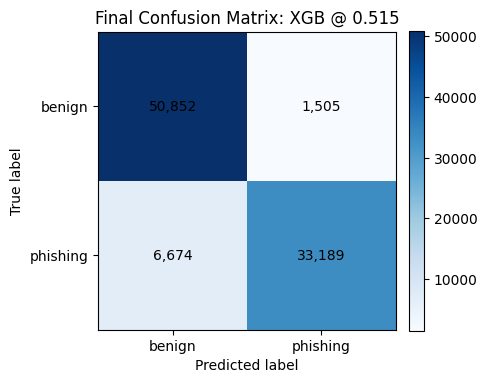

In [6]:
# Display the confusion matrix plot
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(final_confusion_matrix, cmap="Blues")
ax.set_title(f"Final Confusion Matrix: {FINAL_MODEL_NAME} @ {FINAL_THRESHOLD:.3f}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1], labels=["benign", "phishing"])
ax.set_yticks([0, 1], labels=["benign", "phishing"])
for i in range(final_confusion_matrix.shape[0]):
    for j in range(final_confusion_matrix.shape[1]):
        ax.text(j, i, f"{final_confusion_matrix[i, j]:,}", ha="center", va="center")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 4. Evaluation

The selected threshold is applied once to the held-out test split to report the final classification metrics.

In [7]:
# Display a summary table for the final selected model and threshold
pd.DataFrame({
    "metric": ["Final model", "Score column", "Validation rows", "Test rows", "Final threshold type", "Final threshold"],
    "value": [FINAL_MODEL_NAME, SCORE_COLUMN, len(val_pred_df), len(test_pred_df), FINAL_THRESHOLD_NAME, FINAL_THRESHOLD],
})

,metric,value
0,Final model,XGB
1,Score column,pred_prob
2,Validation rows,76939
3,Test rows,92220
4,Final threshold type,best_f1
5,Final threshold,0.515


### 4.1 Explainability

After threshold selection is fixed, the selected XGBoost model is aligned with the saved test rows for SHAP-based interpretation.

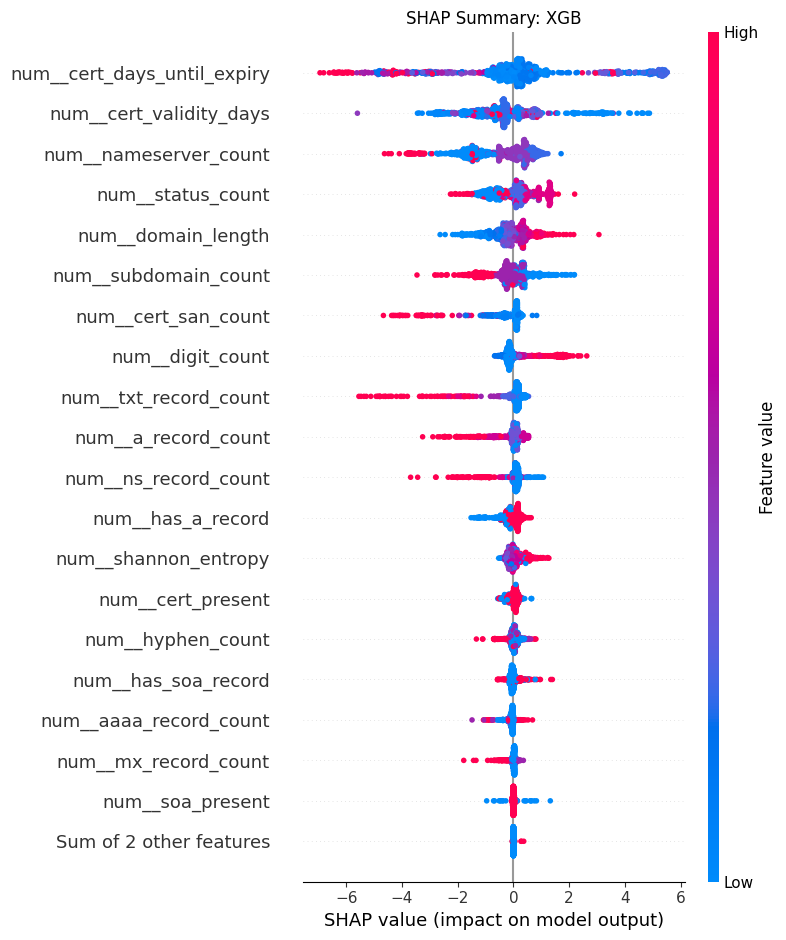

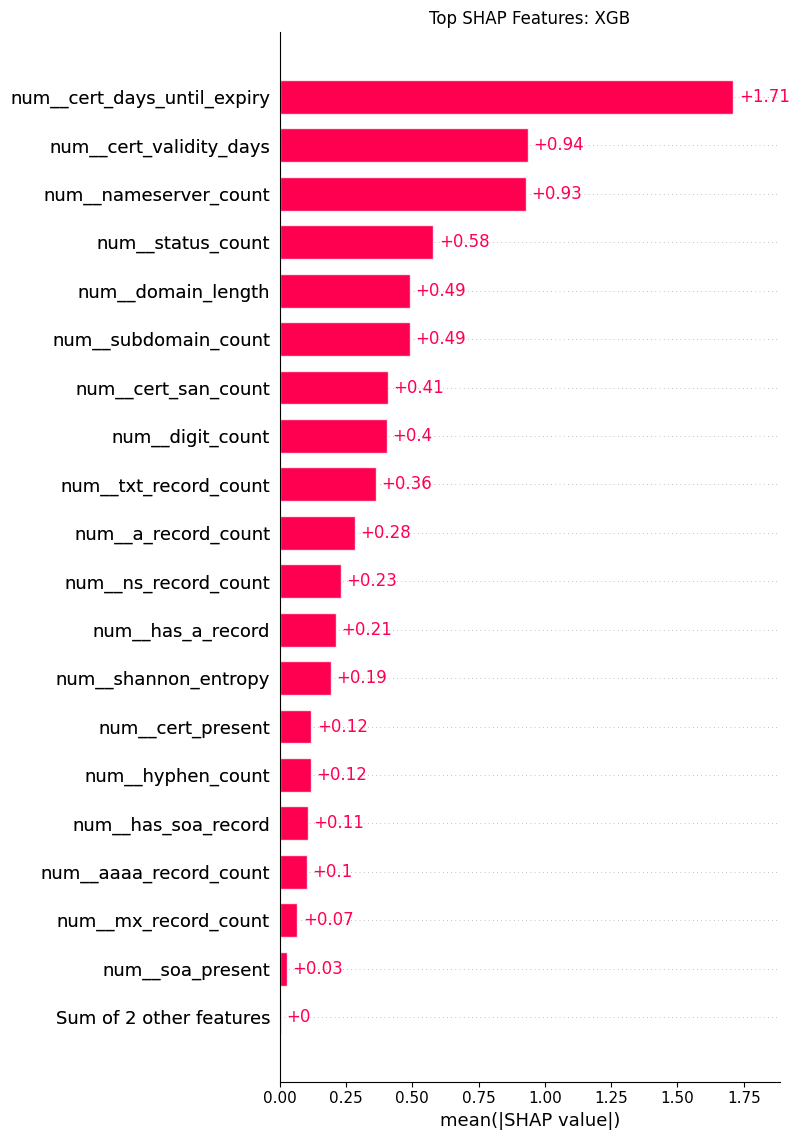

In [8]:
import shap

# Set the maximum number of test rows used for global SHAP plots
MAX_SHAP_GLOBAL_ROWS = 1_000

# Set the maximum number of features displayed in SHAP summary plots
MAX_SHAP_DISPLAY_FEATURES = 20

# Set the maximum number of features listed for each local SHAP explanation
MAX_LOCAL_SHAP_FEATURES = 5

# Resolve the saved model path for the selected final XGBoost candidate
def final_xgboost_model_path(model_name: str) -> Path:
    # Return the baseline XGBoost artefact path
    if model_name == "XGB":
        return OUTPUTS_MODELS_DIR / "xgboost_baseline.joblib"
    # Return the tuned XGBoost artefact path
    if model_name == "XGB_tuned":
        return OUTPUTS_MODELS_DIR / "xgboost_tuned.joblib"
    # Return the hybrid tuned XGBoost artefact path
    if model_name.endswith("+XGB_tuned"):
        anomaly_name = model_name.split("+", 1)[0].lower()
        return OUTPUTS_MODELS_DIR / f"hybrid_xgb_tuned_{anomaly_name}.joblib"
    return

# Convert raw SHAP output into a consistent SHAP Explanation object
def to_shap_explanation(raw_explanation: Any, data: np.ndarray, feature_names: list[str]) -> shap.Explanation:
    # Extract SHAP values and base values
    values = raw_explanation.values
    base_values = raw_explanation.base_values
    # Select the positive-class SHAP values for binary classifiers with class-wise output
    if values.ndim == 3:
        values = values[:, :, 1]
        if np.asarray(base_values).ndim == 2:
            base_values = np.asarray(base_values)[:, 1]
    # Return a standardised SHAP Explanation object
    return shap.Explanation(
        values=values,
        base_values=base_values,
        data=data,
        feature_names=feature_names,
    )

# Select representative local cases for SHAP explanation
def select_local_shap_indices(y_true: np.ndarray, scores: np.ndarray, y_pred: np.ndarray) -> list[tuple[str, int]]:
    # Track selected case labels and row indices
    selected: list[tuple[str, int]] = []
    # Track already selected rows to avoid duplicates
    used: set[int] = set()

    # Add one representative row for a requested case type
    def add_case(case_type: str, candidate_idx: np.ndarray, rank_descending: bool = True) -> None:
        # Skip case types with no matching candidates
        if len(candidate_idx) == 0:
            return
        # Rank candidates by model score
        order = np.argsort(scores[candidate_idx])
        if rank_descending:
            order = order[::-1]
        # Add the first unused candidate row
        for idx in candidate_idx[order]:
            idx = int(idx)
            if idx not in used:
                selected.append((case_type, idx))
                used.add(idx)
                return
                
    # Select representative true positive, false positive, and false negative cases
    add_case("true_positive", np.where((y_true == 1) & (y_pred == 1))[0], True)
    add_case("false_positive", np.where((y_true == 0) & (y_pred == 1))[0], True)
    add_case("false_negative", np.where((y_true == 1) & (y_pred == 0))[0], True)
    # Select the highest-risk predicted phishing row as an additional case
    predicted_phishing = np.where(y_pred == 1)[0]
    add_case("highest_risk_predicted_phishing", predicted_phishing if len(predicted_phishing) else np.arange(len(scores)), True)
    # Return up to four local explanation cases
    return selected[:4]

# Format the strongest positive or negative SHAP contributors for one row
def top_shap_features(values: np.ndarray, feature_names: list[str], positive: bool, n: int = MAX_LOCAL_SHAP_FEATURES) -> str:
    # Sort feature contributions by SHAP value
    order = np.argsort(values)
    if positive:
        order = order[::-1]
    # Collect matching positive or negative contributors
    rows = []
    for feature_idx in order:
        value = float(values[feature_idx])
        # Skip values with the opposite contribution direction
        if positive and value <= 0:
            continue
        if not positive and value >= 0:
            continue
        # Add the formatted feature contribution
        rows.append(f"{feature_names[feature_idx]} ({value:.3f})")
        # Stop after the requested number of features
        if len(rows) == n:
            break
    # Return formatted contributors or none when no matching features exist
    return "; ".join(rows) if rows else "none"

# Select stable key columns shared by the manifest and candidate dataframe
def manifest_key_columns(manifest_df: pd.DataFrame, candidate_df: pd.DataFrame) -> list[str]:
    # Define preferred alignment keys in priority order
    preferred = ["domain", "registered_domain", "observed_at", "label", "source_dataset"]
    # Keep keys that exist in both dataframes
    keys = [column for column in preferred if column in manifest_df.columns and column in candidate_df.columns]
    # Stop if no shared alignment keys are available
    if not keys:
        raise ValueError("No stable alignment keys available between split manifest and candidate frame.")
    # Return the shared alignment keys
    return keys

# Build the final model matrix used for SHAP explanations
def build_final_xgboost_shap_matrix() -> tuple[Any, np.ndarray, list[str], pd.DataFrame]:
    # Resolve the selected final model path
    model_path = final_xgboost_model_path(FINAL_MODEL_NAME)
    # Define candidate feature metadata paths
    feature_schema_candidates = [
        OUTPUTS_MODELS_DIR / "feature_names.json",
    ]
    # Load feature metadata, preprocessor, and selected model artefact
    feature_metadata = load_json(next((path for path in feature_schema_candidates if path.exists()), feature_schema_candidates[0]))
    preprocessor = joblib.load(OUTPUTS_MODELS_DIR / "preprocessor.joblib")
    model = joblib.load(model_path)
    # Load the feature-engineered dataset from Notebook 2
    feature_table_path = PROCESSED / "combined_feature_engineered.csv"
    feature_df = pd.read_csv(feature_table_path, low_memory=False)
    # Select test rows from the split manifest
    test_manifest_df = split_manifest_df[split_manifest_df["split"].eq("test")].reset_index(drop=True)
    # Align feature rows to the test manifest
    key_columns = manifest_key_columns(test_manifest_df, feature_df)
    shap_test_df = align_frame_to_manifest(
        test_manifest_df,
        feature_df,
        key_columns=key_columns,
        candidate_columns=list(feature_df.columns),
        label="feature table test rows",
    )
    # Transform raw test features through the saved preprocessor
    input_features = feature_metadata.get("model_features", feature_metadata["input_features"])
    # Check that transformed feature width matches saved feature names
    X_test_base = preprocessor.transform(shap_test_df[input_features])
    feature_names = feature_metadata["preprocessor_output"]
    if X_test_base.shape[1] != len(feature_names):
        raise ValueError(
            "Preprocessor output width mismatch in Notebook 3: "
            f"expected {len(feature_names)} columns but got {X_test_base.shape[1]}"
        )
    # Return base model inputs when the selected model is not hybrid
    if "+" not in FINAL_MODEL_NAME:
        return model, X_test_base, feature_names, shap_test_df
    # Resolve saved anomaly scores for the hybrid model
    anomaly_name = FINAL_MODEL_NAME.split("+", 1)[0]
    anomaly_path = resolve_output_path(
        OUTPUTS_DIR,
        [
            f"notebook2_test_predictions_unsupervised_{anomaly_name.lower()}.csv",
            f"test_predictions_unsupervised_{anomaly_name.lower()}.csv",
        ],
        "saved anomaly scores",
    )
    # Load and align anomaly scores to the test manifest
    anomaly_df = pd.read_csv(anomaly_path)
    anomaly_key_columns = manifest_key_columns(test_manifest_df, anomaly_df)
    aligned_anomaly_df = align_frame_to_manifest(
        test_manifest_df,
        anomaly_df,
        key_columns=anomaly_key_columns,
        candidate_columns=anomaly_key_columns + ["anomaly_score"],
        label="saved anomaly scores",
    )
    # Scale the anomaly score using the saved hybrid scaler
    anomaly_score_scaler = joblib.load(OUTPUTS_MODELS_DIR / "hybrid_anomaly_score_scaler.joblib")
    anomaly_feature = anomaly_score_scaler.transform(aligned_anomaly_df["anomaly_score"].to_numpy().reshape(-1, 1))
    # Append the anomaly score to the base feature matrix
    X_test_model = np.column_stack([X_test_base, anomaly_feature])
    feature_names = feature_metadata["model_features_aug"]
    # Return the model, SHAP matrix, feature names, and aligned test rows
    return model, X_test_model, feature_names, shap_test_df

# Build model inputs for SHAP explanations
final_xgb_model, X_test_shap, shap_feature_names, shap_test_df = build_final_xgboost_shap_matrix()

# Create a reproducible random generator for SHAP row sampling
rng = np.random.default_rng(42)
# Sample test rows for global SHAP plots when the test set is large
if X_test_shap.shape[0] > MAX_SHAP_GLOBAL_ROWS:
    shap_global_idx = np.sort(rng.choice(X_test_shap.shape[0], size=MAX_SHAP_GLOBAL_ROWS, replace=False))
else:
    shap_global_idx = np.arange(X_test_shap.shape[0])
    
# Build the sampled matrix for global SHAP explanations
X_shap_global = X_test_shap[shap_global_idx]

# Create a tree explainer for the selected XGBoost model
explainer = shap.TreeExplainer(final_xgb_model)

# Calculate global SHAP explanations for sampled test rows
shap_global = to_shap_explanation(explainer(X_shap_global), X_shap_global, shap_feature_names)

# Plot the global SHAP beeswarm summary
shap.plots.beeswarm(shap_global, max_display=MAX_SHAP_DISPLAY_FEATURES, show=False)
plt.title(f"SHAP Summary: {FINAL_MODEL_NAME}")
plt.tight_layout()
plt.show()

# Plot the top global SHAP feature importance bars
shap.plots.bar(shap_global, max_display=MAX_SHAP_DISPLAY_FEATURES, show=False)
plt.title(f"Top SHAP Features: {FINAL_MODEL_NAME}")
plt.tight_layout()
plt.show()

# Select representative test cases for local SHAP explanations
local_cases = select_local_shap_indices(test_y, test_scores, final_test_pred)

# Build local SHAP explanations when representative cases are available
if local_cases:
    # Extract selected local row indices
    local_indices = [idx for _, idx in local_cases]
    # Calculate SHAP explanations for selected local rows
    shap_local = to_shap_explanation(explainer(X_test_shap[local_indices]), X_test_shap[local_indices], shap_feature_names)
    # Collect local explanation rows
    local_rows = []
    # Summarise each local explanation case
    for local_pos, (case_type, row_idx) in enumerate(local_cases):
        values = shap_local.values[local_pos]
        # Store identifiers, prediction values, and top SHAP contributors
        local_rows.append({
            "case_type": case_type,
            "row_index": int(row_idx),
            "domain": test_pred_df.iloc[row_idx].get("domain", row_idx),
            "true_label": int(test_y[row_idx]),
            "predicted_probability": float(test_scores[row_idx]),
            "predicted_label": int(final_test_pred[row_idx]),
            "threshold": float(FINAL_THRESHOLD),
            "top_positive_contributing_features": top_shap_features(values, shap_feature_names, positive=True),
            "top_negative_contributing_features": top_shap_features(values, shap_feature_names, positive=False),
        })
        
    # Build the local SHAP explanation table
    local_shap_table = pd.DataFrame(local_rows)